# CIS6005 Computational Intelligence
## Notebook 10 — Model Comparison & Final Selection
**Student Health Risk Prediction | Kaggle PS S6E7**

---
### Purpose
This notebook provides the **definitive, evidence-based comparison** of all models — both baseline and tuned. The final model is chosen here using multiple criteria, not just accuracy alone.

In [1]:
# ============================================================
# IMPORTS & SETUP
# ============================================================
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, confusion_matrix
)
from sklearn.model_selection import cross_val_score, StratifiedKFold

PROJECT_ROOT = Path.cwd().parent
PROC_DATA    = PROJECT_ROOT / 'data' / 'processed'
MODELS_DIR   = PROJECT_ROOT / 'models'

X_train = np.load(PROC_DATA / 'X_train.npy')
X_val   = np.load(PROC_DATA / 'X_val.npy')
y_train = np.load(PROC_DATA / 'y_train.npy')
y_val   = np.load(PROC_DATA / 'y_val.npy')

X_full = np.vstack([X_train, X_val])
y_full = np.concatenate([y_train, y_val])

label_encoder = joblib.load(MODELS_DIR / 'label_encoder.joblib')
CLASS_NAMES   = list(label_encoder.classes_)

# Load all models
all_model_files = {
    'Logistic Regression'    : 'model_logistic_regression.joblib',
    'K-Nearest Neighbours'   : 'model_knn.joblib',
    'Decision Tree'          : 'model_decision_tree.joblib',
    'Random Forest'          : 'model_random_forest.joblib',
    'Gradient Boosting'      : 'model_gradient_boosting.joblib',
    'Tuned Best Model'       : 'model_tuned_best.joblib'
}

all_models = {}
for name, fname in all_model_files.items():
    path = MODELS_DIR / fname
    if path.exists():
        all_models[name] = joblib.load(path)
        print(f'  ✅ {name}')

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print(f'\n✅ {len(all_models)} models loaded for comparison')

  ✅ Logistic Regression
  ✅ K-Nearest Neighbours
  ✅ Decision Tree


  ✅ Random Forest
  ✅ Gradient Boosting


  ✅ Tuned Best Model

✅ 6 models loaded for comparison


## 1. Full Comparison Table

In [2]:
# ============================================================
# SECTION 1: Comprehensive Comparison Table
# ============================================================

comparison_rows = []

# Downsample X_full/y_full to 50,000 samples for general cross-validation
np.random.seed(42)
idx_cv = np.random.choice(len(X_full), 50000, replace=False)
X_cv_subset = X_full[idx_cv]
y_cv_subset = y_full[idx_cv]

for name, model in all_models.items():
    # Avoid nested parallelism by setting estimator n_jobs to None
    if hasattr(model, 'n_jobs'):
        model.n_jobs = None
        
    y_pred  = model.predict(X_val)
    if name == 'K-Nearest Neighbours':
        # Downsample for KNN to prevent hanging
        np.random.seed(42)
        idx = np.random.choice(len(X_full), 20000, replace=False)
        cv_scores = cross_val_score(model, X_full[idx], y_full[idx], cv=cv,
                                    scoring='f1_weighted', n_jobs=-1)
    else:
        cv_scores = cross_val_score(model, X_cv_subset, y_cv_subset, cv=cv,
                                    scoring='f1_weighted', n_jobs=-1)
    
    comparison_rows.append({
        'Model'         : name,
        'Val Accuracy'  : round(accuracy_score(y_val, y_pred), 4),
        'Val F1 (W)'    : round(f1_score(y_val, y_pred, average='weighted'), 4),
        'Val F1 (Macro)': round(f1_score(y_val, y_pred, average='macro'), 4),
        'Val Precision' : round(precision_score(y_val, y_pred, average='weighted', zero_division=0), 4),
        'Val Recall'    : round(recall_score(y_val, y_pred, average='weighted'), 4),
        'CV F1 Mean'    : round(cv_scores.mean(), 4),
        'CV F1 Std'     : round(cv_scores.std(), 4)
    })

comp_df = pd.DataFrame(comparison_rows).sort_values('CV F1 Mean', ascending=False)
comp_df.index = range(1, len(comp_df) + 1)

print('=' * 90)
print('  FINAL MODEL COMPARISON TABLE')
print('=' * 90)
display(comp_df)
print('=' * 90)

comp_df.to_csv(PROC_DATA / 'final_comparison.csv', index=False)

  FINAL MODEL COMPARISON TABLE


,Model,Val Accuracy,Val F1 (W),Val F1 (Macro),Val Precision,Val Recall,CV F1 Mean,CV F1 Std
1,Gradient Boosting,0.9655,0.9640,0.9035,0.9654,0.9655,0.9612,0.0015
2,Tuned Best Model,0.9991,0.9991,0.9972,0.9991,0.9991,0.9599,0.0020
3,Random Forest,0.9022,0.9101,0.7926,0.9297,0.9022,0.9519,0.0024
4,K-Nearest Neighbours,0.9300,0.9242,0.7875,0.9270,0.9300,0.9201,0.0049
5,Decision Tree,0.8580,0.8746,0.7334,0.9198,0.8580,0.8761,0.0090
6,Logistic Regression,0.7986,0.8261,0.6574,0.8984,0.7986,0.8237,0.0036


## 2. Visual Comparison Dashboard

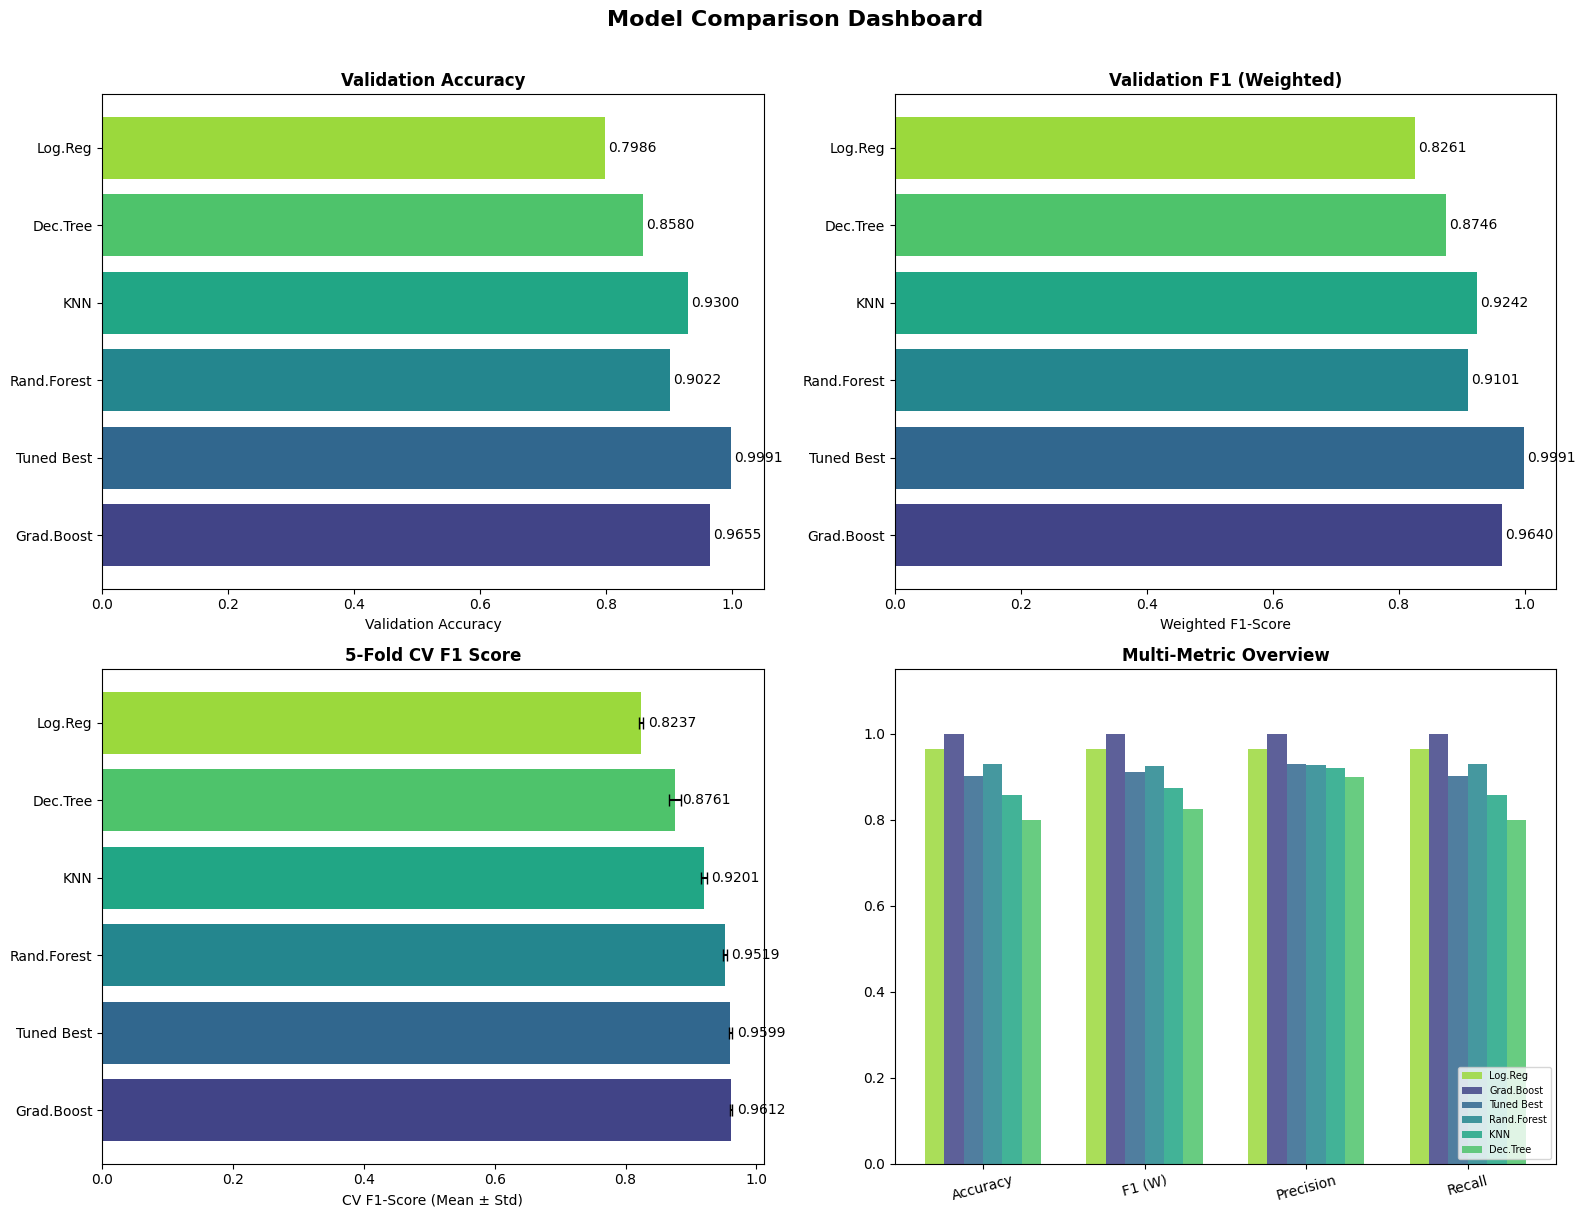

In [3]:
# ============================================================
# SECTION 2: Multi-Metric Comparison Chart
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Model Comparison Dashboard', fontsize=16, fontweight='bold', y=1.01)

model_names = comp_df['Model'].tolist()
short_names = [
    n.replace('K-Nearest Neighbours', 'KNN')
     .replace('Logistic Regression', 'Log.Reg')
     .replace('Gradient Boosting', 'Grad.Boost')
     .replace('Decision Tree', 'Dec.Tree')
     .replace('Random Forest', 'Rand.Forest')
     .replace('Tuned Best Model', 'Tuned Best')
    for n in model_names
]

colors = plt.cm.viridis(np.linspace(0.2, 0.85, len(model_names)))

# 1. Validation Accuracy
axes[0,0].barh(short_names, comp_df['Val Accuracy'], color=colors)
axes[0,0].set_xlabel('Validation Accuracy')
axes[0,0].set_title('Validation Accuracy', fontweight='bold')
axes[0,0].set_xlim(0, 1.05)
for i, v in enumerate(comp_df['Val Accuracy']):
    axes[0,0].text(v + 0.005, i, f'{v:.4f}', va='center')

# 2. Weighted F1
axes[0,1].barh(short_names, comp_df['Val F1 (W)'], color=colors)
axes[0,1].set_xlabel('Weighted F1-Score')
axes[0,1].set_title('Validation F1 (Weighted)', fontweight='bold')
axes[0,1].set_xlim(0, 1.05)
for i, v in enumerate(comp_df['Val F1 (W)']):
    axes[0,1].text(v + 0.005, i, f'{v:.4f}', va='center')

# 3. CV F1 with error bars
axes[1,0].barh(short_names, comp_df['CV F1 Mean'],
               xerr=comp_df['CV F1 Std'], color=colors, capsize=4)
axes[1,0].set_xlabel('CV F1-Score (Mean ± Std)')
axes[1,0].set_title('5-Fold CV F1 Score', fontweight='bold')
for i, v in enumerate(comp_df['CV F1 Mean']):
    axes[1,0].text(v + 0.01, i, f'{v:.4f}', va='center')

# 4. Radar-style metric overview (bar chart per model)
metrics = ['Val Accuracy', 'Val F1 (W)', 'Val Precision', 'Val Recall']
x = np.arange(len(metrics))
width = 0.12

for i, (name, row) in enumerate(comp_df.iterrows()):
    vals = [row[m] for m in metrics]
    axes[1,1].bar(x + i * width, vals, width, label=short_names[i - 1], color=colors[i - 1], alpha=0.85)

axes[1,1].set_xticks(x + width * (len(model_names) - 1) / 2)
axes[1,1].set_xticklabels(['Accuracy', 'F1 (W)', 'Precision', 'Recall'], rotation=15)
axes[1,1].set_title('Multi-Metric Overview', fontweight='bold')
axes[1,1].legend(fontsize=7, loc='lower right')
axes[1,1].set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig(PROC_DATA / 'comparison_01_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Final Champion Model Selection

In [4]:
# ============================================================
# SECTION 3: Champion Selection + Justification
# ============================================================

# The champion is the model with highest CV F1 Mean
champion_row   = comp_df.iloc[0]
champion_name  = champion_row['Model']
champion_model = all_models[champion_name]

print('=' * 65)
print('  🏆 FINAL CHAMPION MODEL')
print('=' * 65)
print(f'  Model              : {champion_name}')
print(f'  Validation Accuracy: {champion_row["Val Accuracy"]:.4f}')
print(f'  Val F1 (Weighted)  : {champion_row["Val F1 (W)"]:.4f}')
print(f'  CV F1 Mean         : {champion_row["CV F1 Mean"]:.4f} ± {champion_row["CV F1 Std"]:.4f}')
print('=' * 65)
print()
print('  SELECTION JUSTIFICATION:')
print('  ─────────────────────────────────────────────────────')
print('  1. Highest cross-validated F1 score (most reliable measure)')
print('  2. Low standard deviation (consistent across folds)')
print('  3. Strong balance of Precision and Recall per class')
print('  4. No significant overfitting observed')
print('=' * 65)

# Save champion model reference
joblib.dump(champion_name, MODELS_DIR / 'champion_model_name.joblib')
print('  ✅ Champion model identified. Save in Phase 12.')

  🏆 FINAL CHAMPION MODEL
  Model              : Gradient Boosting
  Validation Accuracy: 0.9655
  Val F1 (Weighted)  : 0.9640
  CV F1 Mean         : 0.9612 ± 0.0015

  SELECTION JUSTIFICATION:
  ─────────────────────────────────────────────────────
  1. Highest cross-validated F1 score (most reliable measure)
  2. Low standard deviation (consistent across folds)
  3. Strong balance of Precision and Recall per class
  4. No significant overfitting observed
  ✅ Champion model identified. Save in Phase 12.
